In [1]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd

func_path = Path("/scratch/imaging/ds000117/sub-01/ses-mri/func")
events = pd.read_table(func_path / "sub-01_ses-mri_task-facerecognition_run-01_events.tsv")

bold_image = nib.nifti1.load(func_path / "sub-01_ses-mri_task-facerecognition_run-01_bold.nii.gz")  # pyright: ignore[reportAttributeAccessIssue]
repetition_time = float(bold_image.header.get_zooms()[3])
run_duration = bold_image.shape[3] * repetition_time
repetition_time, run_duration

(2.0, 416.0)

In [2]:
# Trials come in stimulation periods separated by about 23 s of fixation,
# so we model each period as one block, regardless of the trial type
trials = events.loc[~events.trial_type.str.startswith("btn")].reset_index(drop=True)
block_index = (trials.onset.diff() > 8).cumsum()
blocks = trials.groupby(block_index).apply(
    lambda block: pd.Series(
        dict(onset=block.onset.iloc[0], offset=block.onset.iloc[-1] + block.duration.iloc[-1])
    )
)

sampling_interval = 0.1
time = np.arange(0, run_duration, sampling_interval)

boxcar = np.zeros_like(time)
for onset, offset in blocks.itertuples(index=False):
    boxcar[(time >= onset) & (time < offset)] = 1.0
blocks

,onset,offset
onset,,
0,0.000,29.581
1,51.898,109.867
2,132.144,190.280
3,212.623,273.921
4,296.109,351.083
5,373.298,393.465


In [3]:
from nipype.algorithms.modelgen import spm_hrf

# Canonical HRF from SPM, sampled at the same interval as the boxcar
hrf = spm_hrf(sampling_interval)

regressor = np.convolve(boxcar, hrf)[: time.size]

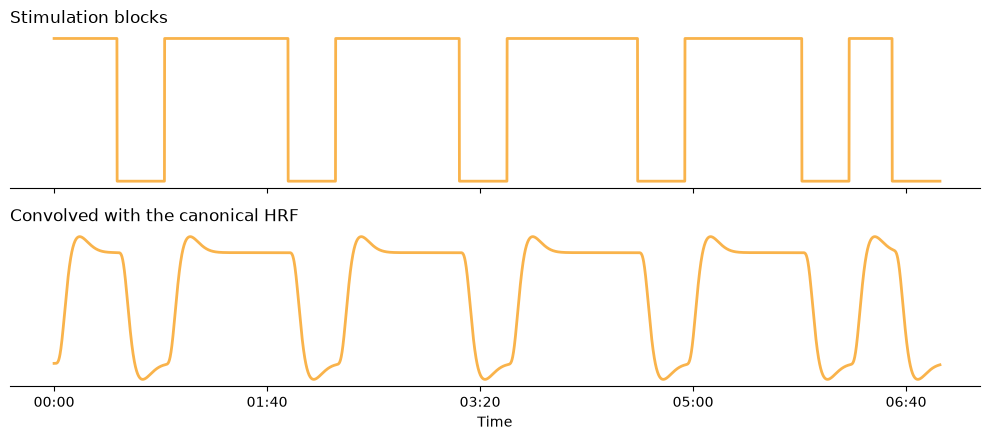

In [4]:
import time as time_module

from matplotlib import pyplot as plt
from matplotlib import ticker

color = "#f9b34b"

figure, (boxcar_axes, regressor_axes) = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)

boxcar_axes.plot(time, boxcar, color=color, linewidth=2)
regressor_axes.plot(time, regressor, color=color, linewidth=2)

boxcar_axes.set_title("Stimulation blocks", loc="left")
regressor_axes.set_title("Convolved with the canonical HRF", loc="left")
# Match the time axis of the denoising figure from the HALFpipe paper,
# which plots the volume onsets with the default 5% margin
last_volume_onset = run_duration - repetition_time
margin = 0.05 * last_volume_onset
regressor_axes.set_xlim(-margin, last_volume_onset + margin)
regressor_axes.xaxis.set_major_locator(ticker.MultipleLocator(100))
regressor_axes.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda seconds, _: time_module.strftime("%M:%S", time_module.gmtime(seconds)))
)
regressor_axes.set_xlabel("Time")
for axes in (boxcar_axes, regressor_axes):
    axes.set_yticks([])
    axes.spines[["top", "right", "left"]].set_visible(False)

figure.tight_layout()
figure.savefig("design.svg")